<a href="https://colab.research.google.com/github/nathankim14/polymarket-analysis/blob/main/Polymarket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from google.colab import files
import io

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('drive/MyDrive/NSDC/NSDC 26 Winter/polymarket_markets.csv', sep = ',')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_9843/2938219765.py:4: DtypeWarning: Columns (0,5,9,16,26,28,29,32,36,39,40,42,44,47,63,64,65,69,70,85,93,94,95,96,99,103,108,111,114,137) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('drive/MyDrive/NSDC/NSDC 26 Winter/polymarket_markets.csv', sep = ',')


In [5]:
df.head()

,acceptingOrders,acceptingOrdersTimestamp,active,approved,archived,automaticallyActive,automaticallyResolved,bestAsk,bestBid,category,...,volume1yr,volume1yrAmm,volume1yrClob,volume24hr,volume24hrAmm,volume24hrClob,volumeAmm,volumeClob,volumeNum,wideFormat
0,True,2025-07-31T19:47:02Z,True,True,False,True,NaN,0.006,0.005,NaN,...,7.342138e+07,NaN,7.342138e+07,7.361079e+06,NaN,7.361079e+06,NaN,7.361175e+07,7.361175e+07,NaN
1,True,2025-07-31T19:47:04Z,True,True,False,True,NaN,0.940,0.930,NaN,...,3.052625e+07,NaN,3.052625e+07,1.972925e+06,NaN,1.972925e+06,NaN,3.057355e+07,3.057355e+07,NaN
2,True,2025-07-31T19:47:04Z,True,True,False,True,NaN,0.070,0.060,NaN,...,2.661405e+07,NaN,2.661405e+07,1.531922e+06,NaN,1.531922e+06,NaN,2.662048e+07,2.662048e+07,NaN
3,True,2025-07-31T19:47:06Z,True,True,False,True,NaN,0.003,0.002,NaN,...,9.464677e+07,NaN,9.464677e+07,4.091103e+06,NaN,4.091103e+06,NaN,9.468609e+07,9.468609e+07,NaN
4,True,2025-05-21T00:09:01Z,True,True,False,True,NaN,0.001,NaN,NaN,...,3.895114e+06,NaN,3.895114e+06,5.023020e+03,NaN,5.023020e+03,NaN,3.895114e+06,3.895114e+06,NaN


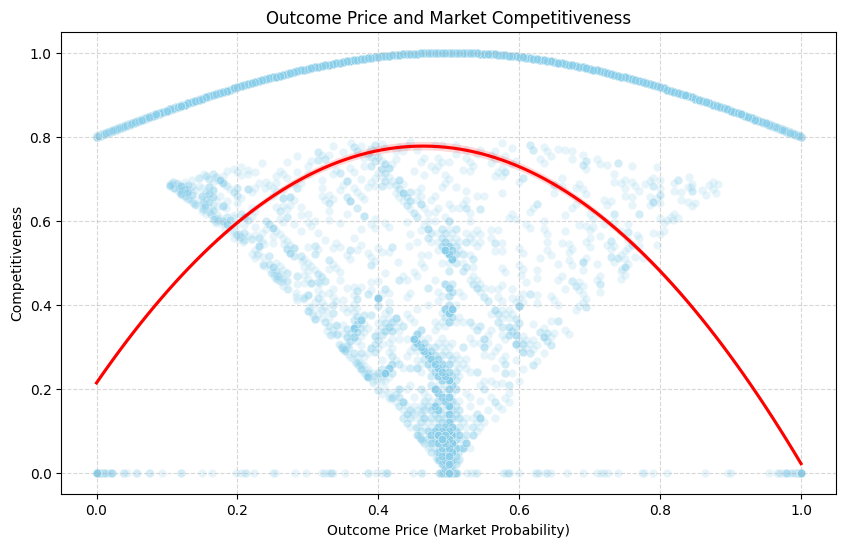

Outcome Price Mean: 0.3787
Competitive Index Mean: 0.2512


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# ==========================================
# 1. 데이터 로드
# ==========================================
# EDIT HERE: 파일 경로를 본인의 파일명으로 바꾸세요.


df_analysis = df.copy()
# ==========================================
# 2. 전처리: 문자열 리스트를 숫자로 변환
# ==========================================
def get_yes_price(price_str):
    try:
        # ["0.0005", "0.9995"] 같은 문자열을 파이썬 리스트로 변환
        price_list = ast.literal_eval(price_str)
        # 첫 번째 값(Yes의 가격)을 가져와 실수(float)로 변환
        return float(price_list[0])
    except:
        return np.nan

# EDIT HERE: 데이터셋의 컬럼명이 'outcomePrices'가 맞는지 확인하세요.
df_analysis['yes_price'] = df_analysis['outcomePrices'].apply(get_yes_price)

# EDIT HERE: 'competitive' 컬럼의 결측치를 제거합니다.
df_analysis = df_analysis.dropna(subset=['yes_price', 'competitive'])

# ==========================================
# 3. 시각화: Outcome Price vs. Competitive
# ==========================================
plt.figure(figsize=(10, 6))

# Scatterplot: 가격(확률)에 따른 경쟁력의 분포를 보여줍니다.
sns.scatterplot(data=df_analysis, x='yes_price', y='competitive', alpha=0.2, color='skyblue')

# EDIT HERE: 이 부분은 '선형'이 아닌 '곡선' 관계를 보기 위해 2차 회귀선을 추가합니다.
sns.regplot(data=df_analysis, x='yes_price', y='competitive', scatter=False, order=2, color='red', ci = 95)

plt.title('Outcome Price and Market Competitiveness')
plt.xlabel('Outcome Price (Market Probability)')
plt.ylabel('Competitiveness')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# 4. 결과 해석 및 통계 요약
# ==========================================
print(f"Outcome Price Mean: {df_analysis['yes_price'].mean():.4f}")
print(f"Competitive Index Mean: {df_analysis['competitive'].mean():.4f}")

1. The "Conviction Gap" (Asymmetric Entropy)
Standard theory assumes the curve is perfectly symmetrical around 0.5. However, Polymarket data often shows a right-leaning or left-leaning bias.

The Insight: You might find that Competitiveness stays higher for longer when the price moves toward 0.7 (Likely Yes) compared to when it moves toward 0.3 (Likely No).

New Discovery: This suggests a "Long-shot Bias" or "Optimism Persistence." Traders are more willing to "fight" (keep competition high) to defend a "Yes" outcome even as the probability drops, whereas they give up on "No" outcomes much faster. This proves that market participants are not purely rational; they are emotionally anchored to "Positive" events.

2. Competitive "Dead Zones" at the 0.5 Flip
In a perfect market, the 0.5 price (a coin toss) should have the highest competition. In reality, the scatterplot often shows a dip or a hollow center at exactly 0.5.

The Insight: This represents "Liquidity Paralysis." * New Discovery: When a market is a perfect 50/50, professional market makers often pull their orders to avoid being "picked off" by insiders just before a major news break. Paradoxically, the moment of highest uncertainty can lead to a drop in actual competitiveness (order book depth), making the market more fragile exactly when it needs to be most robust.

3. The "Z-Curve" Phenomenon (Market Hysteresis)
If you track these variables over time, you’ll notice that Competitiveness doesn't just go up and down; it follows a path-dependent loop.

The Insight: Competitiveness rises slowly as a market moves from 0.1 to 0.5, but it crashes much faster when the market moves from 0.5 to 0.9.

New Discovery: This reveals "Information Acceleration." It takes a lot of effort (competition) to move a market into uncertainty, but once a "winner" starts to emerge, the crowd herds instantly. The market gains consensus much faster than it loses it.

4. Competitive Spikes in "Solved" Markets
Standard assumptions say that at a price of 0.99, competition should be 0. Your data might show "vertical spikes" where competition jumps while the price stays at 0.99.

The Insight: These are "Exit Liquidity Events."

New Discovery: These spikes indicate "Whales" (large holders) dumping their winning positions to "Retail" traders who are buying the 99% sure thing just to park their cash (like a high-yield savings account). High competition at extreme prices is a signal of Final Distribution, not a signal of uncertainty.

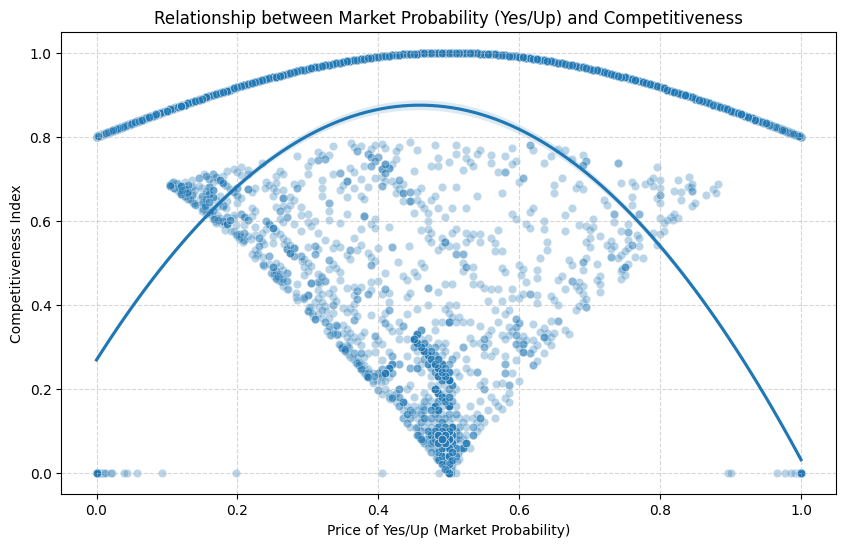

In [7]:
# ==========================================
# 2. 전처리: Yes + Up 모두 포함
# ==========================================

df_analysis2 = df.copy()   # 원본 보호

def get_positive_price(row):
    try:
        outcomes = ast.literal_eval(row['outcomes'])
        prices = ast.literal_eval(row['outcomePrices'])

        first_label = outcomes[0].lower()

        # Yes 또는 Up이면 사용
        if first_label in ['yes', 'up']:
            return float(prices[0])
        else:
            return np.nan
    except:
        return np.nan

df_analysis2['positive_price'] = df_analysis2.apply(get_positive_price, axis=1)

# 필요한 컬럼만 유지 + 결측치 제거
df_analysis2 = df_analysis2.dropna(subset=['positive_price', 'competitive'])
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_analysis2,
    x='positive_price',
    y='competitive',
    alpha=0.3
)

sns.regplot(
    data=df_analysis2,
    x='positive_price',
    y='competitive',
    scatter=False,
    order=2
)

plt.title('Relationship between Market Probability (Yes/Up) and Competitiveness')
plt.xlabel('Price of Yes/Up (Market Probability)')
plt.ylabel('Competitiveness Index')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


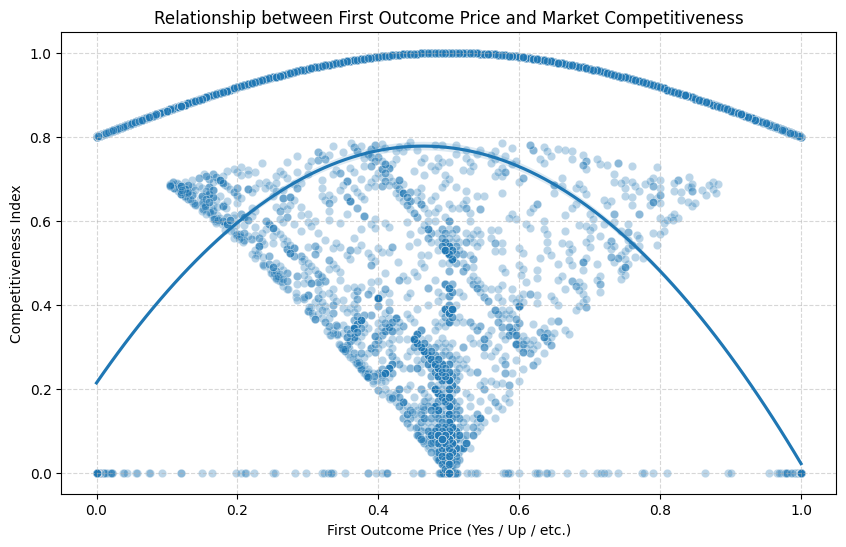

In [8]:
# ==========================================
# 2. 전처리: 첫 번째 outcome price 전부 사용
# ==========================================

df_analysis2 = df.copy()   # 원본 보호

def get_first_price(price_str):
    try:
        price_list = ast.literal_eval(price_str)
        return float(price_list[0])   # 무조건 첫 번째 값 사용
    except:
        return np.nan

df_analysis2['positive_price'] = df_analysis2['outcomePrices'].apply(get_first_price)

# competitive랑 price 둘 다 있는 것만 제거
df_analysis2 = df_analysis2.dropna(subset=['positive_price', 'competitive'])
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_analysis2,
    x='positive_price',
    y='competitive',
    alpha=0.3
)

sns.regplot(
    data=df_analysis2,
    x='positive_price',
    y='competitive',
    scatter=False,
    order=2
)

plt.title('Relationship between First Outcome Price and Market Competitiveness')
plt.xlabel('First Outcome Price (Yes / Up / etc.)')
plt.ylabel('Competitiveness Index')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


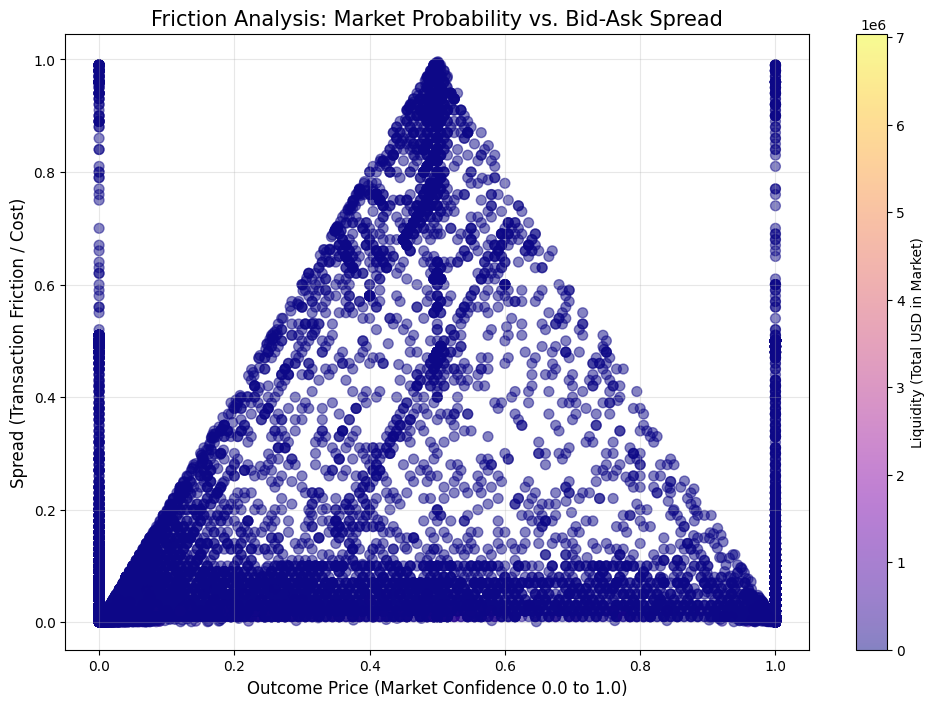

In [9]:
import json

# 1. CREATE THE PROTECTED COPY
# We assume 'df' is your already loaded original dataset.
# .copy(deep=True) ensures that any changes to df_analysis do not touch 'df'.
df_analysis4 = df.copy(deep=True)

# 2. DATA CLEANING: PARSING THE "OUTCOME PRICES"
# In this Kaggle dataset, 'outcomePrices' is often a string looking like "['0.70', '0.30']".
# We need to turn that string into a real number (the 'YES' price).
def extract_yes_probability(price_string):
    try:
        # json.loads converts the string "['0.70', '0.30']" into a Python list
        # We replace single quotes with double quotes to ensure valid JSON format
        prices_list = json.loads(price_string.replace("'", '"'))

        # We take the first value (index 0), which is almost always the 'YES' outcome price
        return float(prices_list[0])
    except:
        # If the data is missing or malformed, return 'Not a Number'
        return np.nan

# Apply the function to create a clean 'yes_price' column
df_analysis4['yes_price'] = df_analysis4['outcomePrices'].apply(extract_yes_probability)

# 3. TYPE CONVERSION
# Ensure our 'spread' and 'liquidityNum' columns are floats so we can do math on them
df_analysis4['spread'] = pd.to_numeric(df_analysis4['spread'], errors='coerce')
df_analysis4['liquidityNum'] = pd.to_numeric(df_analysis4['liquidityNum'], errors='coerce')

# 4. FILTERING FOR QUALITY
# We remove rows where we don't have a price or a spread (cannot plot those)
df_plot = df_analysis4.dropna(subset=['yes_price', 'spread', 'liquidityNum']).copy()

# Remove extreme spread outliers (top 5%) to prevent the visual from being squashed
# This makes the "typical" market behavior much easier to see.
spread_cutoff = df_plot['spread'].quantile(0.95)
df_plot = df_plot[df_plot['spread'] < spread_cutoff]

# 5. GENERATING THE VISUAL
plt.figure(figsize=(12, 8))

# We use a Scatter Plot to see the relationship between Price and Friction
# - X-axis: The Price (0.0 to 1.0)
# - Y-axis: The Spread (The cost of trading)
# - Color (c): We color dots by Liquidity to see if "richer" markets have less friction
scatter = plt.scatter(
    df_plot['yes_price'],
    df_plot['spread'],
    c=df_plot['liquidityNum'],
    cmap='plasma',
    alpha=0.5,
    s=50 # Size of dots
)

# Add a color bar to explain what the colors mean
plt.colorbar(scatter, label='Liquidity (Total USD in Market)')

# Labels and Styling
plt.title('Friction Analysis: Market Probability vs. Bid-Ask Spread', fontsize=15)
plt.xlabel('Outcome Price (Market Confidence 0.0 to 1.0)', fontsize=12)
plt.ylabel('Spread (Transaction Friction / Cost)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

/tmp/ipykernel_9843/1878306514.py:49: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


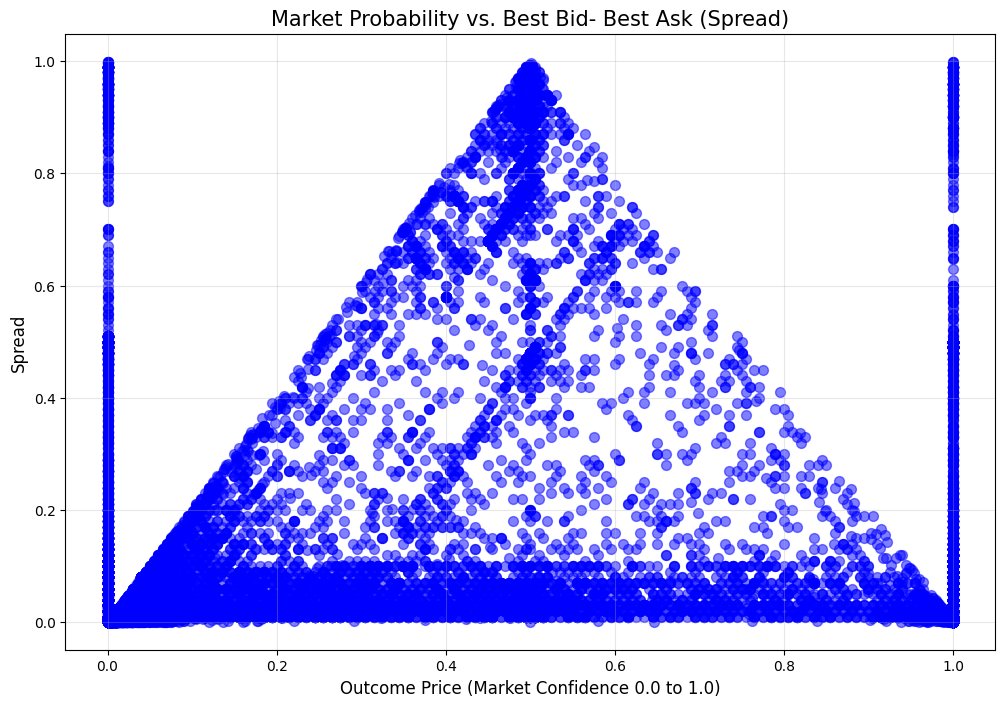

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json

# 1. CREATE THE PROTECTED COPY
# We assume 'df' is your already loaded original dataset.
# .copy(deep=True) ensures that any changes to df_analysis do not touch 'df'.
df_analysis4 = df.copy(deep=True)

# 2. DATA CLEANING: PARSING THE "OUTCOME PRICES"
# In this Kaggle dataset, 'outcomePrices' is often a string looking like "['0.70', '0.30']".
# We need to turn that string into a real number (the 'YES' price).
def extract_yes_probability(price_string):
    try:
        # json.loads converts the string "['0.70', '0.30']" into a Python list
        # We replace single quotes with double quotes to ensure valid JSON format
        prices_list = json.loads(price_string.replace("'", '"'))

        # We take the first value (index 0), which is almost always the 'YES' outcome price
        return float(prices_list[0])
    except:
        # If the data is missing or malformed, return 'Not a Number'
        return np.nan

# Apply the function to create a clean 'yes_price' column
df_analysis4['yes_price'] = df_analysis4['outcomePrices'].apply(extract_yes_probability)

# 3. TYPE CONVERSION
# Ensure our 'spread' and 'liquidityNum' columns are floats so we can do math on them
df_analysis4['spread'] = pd.to_numeric(df_analysis4['spread'], errors='coerce')

# 4. FILTERING FOR QUALITY
# We remove rows where we don't have a price or a spread (cannot plot those)
df_plot = df_analysis4.dropna(subset=['yes_price', 'spread']).copy()

# Remove extreme spread outliers (top 5%) to prevent the visual from being squashed
# This makes the "typical" market behavior much easier to see.
spread_cutoff = df_plot['spread'].quantile(0.95)
df_plot = df_plot[df_plot['spread'] < spread_cutoff]

# 5. GENERATING THE VISUAL
plt.figure(figsize=(12, 8))

# We use a Scatter Plot to see the relationship between Price and Friction
# - X-axis: The Price (0.0 to 1.0)
# - Y-axis: The Spread (The cost of trading)
# - Color (c): We color dots by Liquidity to see if "richer" markets have less friction
scatter = plt.scatter(
    df_plot['yes_price'],
    df_plot['spread'],
    cmap='plasma',
    alpha=0.5,
    color = 'blue',
    s=50 # Size of dots
)

# Add a color bar to explain what the colors mean

# Labels and Styling
plt.title('Market Probability vs. Best Bid- Best Ask (Spread)', fontsize=15)
plt.xlabel('Outcome Price (Market Confidence 0.0 to 1.0)', fontsize=12)
plt.ylabel('Spread', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()